# DIV2K Dataset Loader
**Project:** Lightweight Super-Resolution for Mobile Devices  
**Purpose:** Download and randomly sample 100 images from the DIV2K dataset (HR + LR×2 pairs)  

---
### Strategy for choosing images
DIV2K contains 800 training images and 100 validation images (all high-quality 2K resolution).  
We **randomly sample 200 images from the 800 training images** because:
- The training split is large and diverse enough for random sampling to be representative.
- We fix a random seed so the selection is reproducible across team members.
- We download both the **HR** (high-resolution) and **LR×2** (low-resolution ×2 downscale) versions to form training pairs.

## 0. Install dependencies

In [ ]:
!pip install Pillow matplotlib numpy requests tqdm --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [ ]:
import os
import random
import zipfile
import requests
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Dataset parameters ───────────────────────────────────────────────────────
N_IMAGES      = 100          # how many images to sample
SCALE         = 2            # super-resolution scale factor (×2)
TOTAL_TRAIN   = 800          # total images in DIV2K training split (IDs 0001–0800)

# ── Directory layout ─────────────────────────────────────────────────────────
BASE_DIR = Path("/content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset")
HR_DIR        = BASE_DIR / "HR"
LR_DIR        = BASE_DIR / f"LR_x{SCALE}"
ZIP_DIR       = BASE_DIR / "zips"

for d in [HR_DIR, LR_DIR, ZIP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Directories ready under: {BASE_DIR.resolve()}")

Directories ready under: /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset


In [ ]:
import json

with open("dataset_meta.json", "r") as f:
    cfg = json.load(f)

loaded_ids = set(cfg["selected_ids"])

## 2. Sample 200 random image IDs

In [ ]:
# DIV2K training images are named 0001.png … 0800.png
all_ids = list(range(1, TOTAL_TRAIN + 1))
filtered_ids = [i for i in all_ids if i not in loaded_ids]
selected_ids = sorted(random.sample(filtered_ids, N_IMAGES))  # 100 unique IDs, sorted

print(f"Selected {len(selected_ids)} image IDs (seed={SEED}):")
print(selected_ids)

Selected 100 image IDs (seed=42):
[8, 29, 32, 36, 38, 52, 54, 65, 77, 83, 85, 93, 94, 107, 112, 113, 118, 122, 123, 134, 148, 165, 185, 189, 192, 193, 202, 230, 238, 250, 253, 254, 257, 260, 261, 262, 265, 270, 272, 278, 292, 314, 317, 318, 320, 325, 328, 340, 344, 372, 373, 384, 399, 403, 407, 418, 422, 425, 428, 436, 444, 445, 446, 463, 469, 490, 493, 521, 526, 531, 532, 535, 579, 585, 618, 622, 632, 640, 646, 650, 659, 672, 685, 686, 701, 703, 708, 720, 732, 744, 750, 757, 758, 765, 778, 783, 784, 789, 790, 794]


## 3. Download the DIV2K archives

> **Note:** DIV2K is distributed as zip archives from ETH Zurich (~3.3 GB for HR train, ~880 MB for LR×2 train).  
> The cell below downloads only the two relevant zips. If you already have them, set `SKIP_DOWNLOAD = True`.

| Archive | Contents | Size (approx.) |
|---|---|---|
| `DIV2K_train_HR.zip` | 800 HR images | ~3.3 GB |
| `DIV2K_train_LR_bicubic_X2.zip` | 800 LR×2 images | ~880 MB |

In [ ]:
SKIP_DOWNLOAD = False   # ← set True if you already downloaded the zips

URLS = {
    "HR":  "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
    "LR":  "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_LR_bicubic_X2.zip",
}

def download_file(url: str, dest: Path, chunk_size: int = 1 << 20) -> None:
    """Stream-download a file with a progress bar."""
    if dest.exists():
        print(f"  Already exists, skipping: {dest.name}")
        return
    print(f"  Downloading {dest.name} …")
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    total = int(response.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=chunk_size):
            f.write(chunk)
            bar.update(len(chunk))

if not SKIP_DOWNLOAD:
    download_file(URLS["HR"], ZIP_DIR / "DIV2K_train_HR.zip")
    download_file(URLS["LR"], ZIP_DIR / "DIV2K_train_LR_bicubic_X2.zip")
else:
    print("Download skipped (SKIP_DOWNLOAD=True).")

100%|██████████| 3.53G/3.53G [02:07<00:00, 27.6MB/s]


100%|██████████| 925M/925M [00:38<00:00, 24.3MB/s]


## 4. Extract only the 200 selected images
Instead of unpacking all 800 images, we selectively extract only the files whose IDs are in `selected_ids`. This saves significant disk space.

In [ ]:
def extract_selected(zip_path: Path, out_dir: Path, selected_ids: list,
                     id_format: str = "{:04d}.png") -> None:
    """
    Extract only the files corresponding to selected_ids from a zip archive.

    Parameters
    ----------
    zip_path   : path to the .zip file
    out_dir    : directory where extracted files land
    selected_ids : list of integer image IDs to keep
    id_format  : filename pattern, e.g. '0001.png'
    """
    target_names = {id_format.format(i) for i in selected_ids}
    extracted = 0

    with zipfile.ZipFile(zip_path, "r") as zf:
        all_names = zf.namelist()
        # Match by filename (basename only), ignoring the subfolder path inside zip
        to_extract = [n for n in all_names if Path(n).name in target_names]

        print(f"  Found {len(to_extract)}/{len(target_names)} targets in {zip_path.name}")
        for member in tqdm(to_extract, desc=f"  Extracting → {out_dir.name}"):
            filename = Path(member).name
            dest = out_dir / filename
            if dest.exists():
                continue
            with zf.open(member) as src, open(dest, "wb") as dst:
                dst.write(src.read())
            extracted += 1

    print(f"  Done: {extracted} new files extracted to {out_dir}")


print("Extracting HR images …")
extract_selected(
    ZIP_DIR / "DIV2K_train_HR.zip",
    HR_DIR,
    selected_ids,
)

print("\nExtracting LR×2 images …")
# Inside the LR zip, filenames end with 'x2.png' (e.g. 0001x2.png)
extract_selected(
    ZIP_DIR / "DIV2K_train_LR_bicubic_X2.zip",
    LR_DIR,
    selected_ids,
    id_format="{:04d}x2.png",
)

Extracting HR images …
  Found 100/100 targets in DIV2K_train_HR.zip


  Extracting → HR: 100%|██████████| 100/100 [00:10<00:00,  9.37it/s]


  Done: 100 new files extracted to /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset/HR

Extracting LR×2 images …
  Found 100/100 targets in DIV2K_train_LR_bicubic_X2.zip


  Extracting → LR_x2: 100%|██████████| 100/100 [00:03<00:00, 26.32it/s]

  Done: 100 new files extracted to /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset/LR_x2


## 5. Verify the loaded dataset

In [ ]:
hr_files = sorted(HR_DIR.glob("*.png"))
lr_files = sorted(LR_DIR.glob("*.png"))

print(f"HR images found : {len(hr_files)}")
print(f"LR images found : {len(lr_files)}")

# Quick sanity check – every HR image should have a matching LR pair
hr_ids = {f.stem for f in hr_files}
lr_ids = {f.stem.replace("x2", "") for f in lr_files}
missing = hr_ids - lr_ids

if missing:
    print(f"⚠ Missing LR pairs for IDs: {missing}")
else:
    print("✓ All HR images have matching LR pairs.")

HR images found : 100
LR images found : 100
✓ All HR images have matching LR pairs.


## 6. Inspect image statistics

In [ ]:
hr_widths, hr_heights = [], []
lr_widths, lr_heights = [], []

for hr_path, lr_path in zip(sorted(HR_DIR.glob("*.png")), sorted(LR_DIR.glob("*.png"))):
    with Image.open(hr_path) as img:
        hr_widths.append(img.width)
        hr_heights.append(img.height)
    with Image.open(lr_path) as img:
        lr_widths.append(img.width)
        lr_heights.append(img.height)

print("HR image sizes:")
print(f"  Width  — min: {min(hr_widths)}, max: {max(hr_widths)}, mean: {np.mean(hr_widths):.0f}")
print(f"  Height — min: {min(hr_heights)}, max: {max(hr_heights)}, mean: {np.mean(hr_heights):.0f}")
print()
print("LR×2 image sizes:")
print(f"  Width  — min: {min(lr_widths)}, max: {max(lr_widths)}, mean: {np.mean(lr_widths):.0f}")
print(f"  Height — min: {min(lr_heights)}, max: {max(lr_heights)}, mean: {np.mean(lr_heights):.0f}")

HR image sizes:
  Width  — min: 1296, max: 2040, mean: 1956
  Height — min: 744, max: 2040, mean: 1430

LR×2 image sizes:
  Width  — min: 648, max: 1020, mean: 978
  Height — min: 372, max: 1020, mean: 715


## 7. Visualize a random sample of image pairs

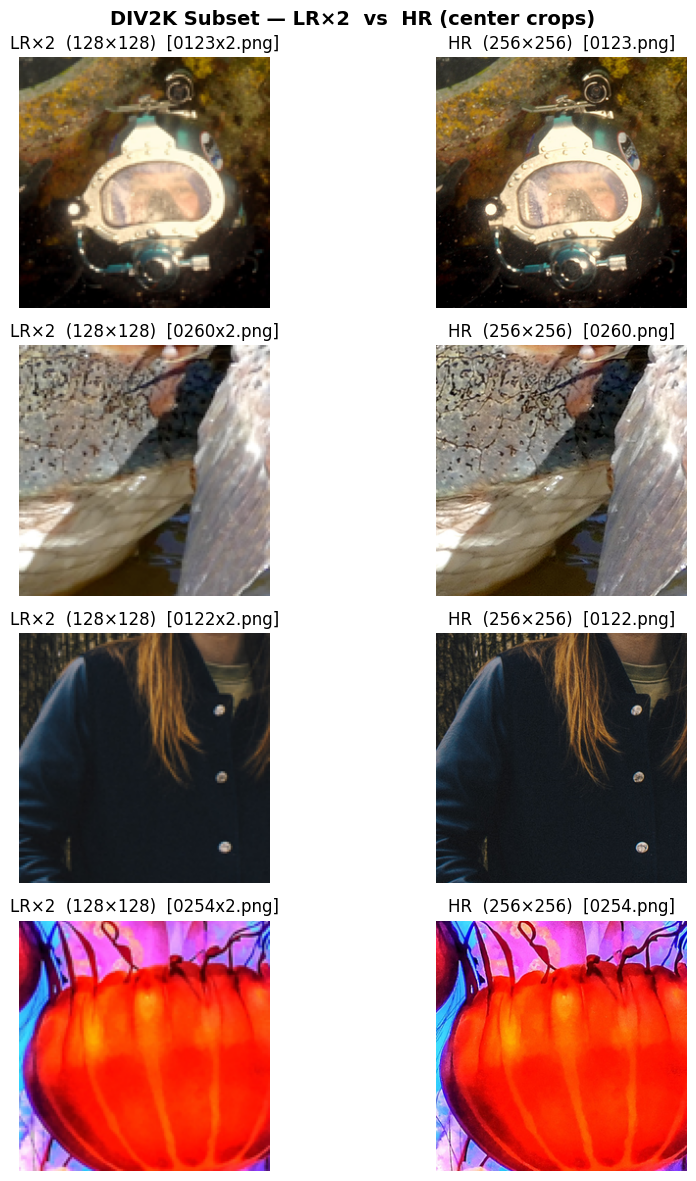

Figure saved → /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset/sample_pairs.png


In [ ]:
N_SHOW   = 4      # how many pairs to display
CROP_SIZE = 256   # display a central crop of this size

hr_list = sorted(HR_DIR.glob("*.png"))
lr_list = sorted(LR_DIR.glob("*.png"))
sample_pairs = random.sample(list(zip(hr_list, lr_list)), N_SHOW)

def center_crop(img: Image.Image, size: int) -> Image.Image:
    w, h = img.size
    left   = (w - size) // 2
    top    = (h - size) // 2
    return img.crop((left, top, left + size, top + size))

fig, axes = plt.subplots(N_SHOW, 2, figsize=(10, 3 * N_SHOW))
fig.suptitle("DIV2K Subset — LR×2  vs  HR (center crops)", fontsize=14, fontweight="bold")

for row, (hr_path, lr_path) in enumerate(sample_pairs):
    hr_img = center_crop(Image.open(hr_path), CROP_SIZE)
    lr_img = center_crop(Image.open(lr_path), CROP_SIZE // SCALE)  # LR is half the size

    axes[row, 0].imshow(lr_img)
    axes[row, 0].set_title(f"LR×{SCALE}  ({lr_img.width}×{lr_img.height})  [{lr_path.name}]")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(hr_img)
    axes[row, 1].set_title(f"HR  ({hr_img.width}×{hr_img.height})  [{hr_path.name}]")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(BASE_DIR / "sample_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {BASE_DIR / 'sample_pairs.png'}")

## 8. Build a simple PyTorch Dataset class
This reusable class will be imported by Student A in the training notebook.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class DIV2KSubset(Dataset):
    """
    PyTorch Dataset for paired LR / HR image patches from DIV2K.

    Parameters
    ----------
    hr_dir     : directory of HR images
    lr_dir     : directory of LR images
    scale      : super-resolution scale factor (default 2)
    patch_size : size of the HR crop used during training
    augment    : whether to apply random horizontal flips
    """

    def __init__(
        self,
        hr_dir: Path,
        lr_dir: Path,
        scale: int = 2,
        patch_size: int = 96,
        augment: bool = True,
    ):
        self.hr_paths   = sorted(hr_dir.glob("*.png"))
        self.lr_paths   = sorted(lr_dir.glob("*.png"))
        assert len(self.hr_paths) == len(self.lr_paths), "HR / LR count mismatch!"

        self.scale      = scale
        self.patch_size = patch_size
        self.augment    = augment
        self.to_tensor  = T.ToTensor()   # converts PIL [0,255] → float [0,1]

    def __len__(self) -> int:
        return len(self.hr_paths)

    def __getitem__(self, idx: int):
        hr = Image.open(self.hr_paths[idx]).convert("RGB")
        lr = Image.open(self.lr_paths[idx]).convert("RGB")

        # ── Random crop (aligned in HR and LR space) ────────────────────────
        ps   = self.patch_size
        lr_ps = ps // self.scale

        lr_w, lr_h = lr.size
        # Pick random top-left corner in LR space
        x = random.randint(0, lr_w - lr_ps)
        y = random.randint(0, lr_h - lr_ps)

        lr_patch = lr.crop((x, y, x + lr_ps, y + lr_ps))
        hr_patch = hr.crop((x * self.scale, y * self.scale,
                            (x + lr_ps) * self.scale, (y + lr_ps) * self.scale))

        # ── Optional augmentation ────────────────────────────────────────────
        if self.augment and random.random() > 0.5:
            lr_patch = lr_patch.transpose(Image.FLIP_LEFT_RIGHT)
            hr_patch = hr_patch.transpose(Image.FLIP_LEFT_RIGHT)

        return self.to_tensor(lr_patch), self.to_tensor(hr_patch)


# ── Quick test ───────────────────────────────────────────────────────────────
dataset = DIV2KSubset(HR_DIR, LR_DIR, scale=SCALE, patch_size=96)
loader  = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

lr_batch, hr_batch = next(iter(loader))
print(f"Dataset size     : {len(dataset)} image pairs")
print(f"LR patch shape   : {lr_batch.shape}   (B, C, H/scale, W/scale)")
print(f"HR patch shape   : {hr_batch.shape}  (B, C, H, W)")
print(f"Pixel value range: [{lr_batch.min():.2f}, {lr_batch.max():.2f}]")

Dataset size     : 100 image pairs
LR patch shape   : torch.Size([4, 3, 48, 48])   (B, C, H/scale, W/scale)
HR patch shape   : torch.Size([4, 3, 96, 96])  (B, C, H, W)
Pixel value range: [0.00, 1.00]


## 9. Save the selected IDs for reproducibility
All three students can load the same 100 images using this file.

In [ ]:
import json

meta = {
    "seed"         : SEED,
    "n_images"     : N_IMAGES,
    "scale"        : SCALE,
    "selected_ids" : selected_ids,
}

meta_path = BASE_DIR / "dataset_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Metadata saved → {meta_path}")
print(json.dumps(meta, indent=2))

Metadata saved → /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/div2k_subset/dataset_meta.json
{
  "seed": 42,
  "n_images": 100,
  "scale": 2,
  "selected_ids": [
    8,
    29,
    32,
    36,
    38,
    52,
    54,
    65,
    77,
    83,
    85,
    93,
    94,
    107,
    112,
    113,
    118,
    122,
    123,
    134,
    148,
    165,
    185,
    189,
    192,
    193,
    202,
    230,
    238,
    250,
    253,
    254,
    257,
    260,
    261,
    262,
    265,
    270,
    272,
    278,
    292,
    314,
    317,
    318,
    320,
    325,
    328,
    340,
    344,
    372,
    373,
    384,
    399,
    403,
    407,
    418,
    422,
    425,
    428,
    436,
    444,
    445,
    446,
    463,
    469,
    490,
    493,
    521,
    526,
    531,
    532,
    535,
    579,
    585,
    618,
    622,
    632,
    640,
    646,
    650,
    659,
    672,
    685,
    686,
    701,
    703,
    708,
    720,
    732,
    744,
    750,
    757,
    7

# Patch Preparation Pipeline
**Input:** 100 DIV2K HR + LR×2 images from `div2k_subset/`  
**Output:** Saved patch dataset in `patch_dataset/` ready for training

### Steps
1. Mod crop — make HR dimensions divisible by scale  
2. Train / val split — 90 train, 10 val (fixed seed)  
3. Patch extraction — stride-based grid with 50% overlap  
4. Augmentation — ×8 variants per patch (flip + 3 rotations)  
5. Normalize — pixels ÷ 255 → [0, 1]  
6. Save to disk — `.npy` files for fast loading during training  

## 0. Imports & configuration

In [ ]:
import os
import json
import random
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────
HR_DIR     = BASE_DIR / "HR"
LR_DIR     = BASE_DIR / "LR_x2"
OUT_DIR  = Path("/content/drive/MyDrive/Deep_learning_project_Queens/new_samples/patches_Dataset")
TRAIN_DIR  = OUT_DIR / "train"
VAL_DIR    = OUT_DIR / "val"
for d in [TRAIN_DIR / "hr", TRAIN_DIR / "lr",
          VAL_DIR   / "hr", VAL_DIR   / "lr"]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
SCALE        = 2       # super-resolution scale factor
HR_PATCH     = 96      # HR patch size  (paper uses 192; 96 is CPU-friendly)
LR_PATCH     = HR_PATCH // SCALE   # 48
STRIDE_HR    = HR_PATCH // 2       # 48  → 50% overlap between patches
STRIDE_LR    = STRIDE_HR // SCALE  # 24
VAL_FRACTION = 0.10    # 10 images reserved for validation

print(f"HR patch : {HR_PATCH}×{HR_PATCH}")
print(f"LR patch : {LR_PATCH}×{LR_PATCH}")
print(f"Stride   : {STRIDE_HR}px (HR) / {STRIDE_LR}px (LR)  → 50% overlap")

HR patch : 96×96
LR patch : 48×48
Stride   : 48px (HR) / 24px (LR)  → 50% overlap


## 1. Mod crop helper
Ensures HR width and height are both divisible by `scale`.  
Without this, the LR and SR images could differ by 1px when reconstructing,
causing dimension-mismatch errors in the loss computation.

In [ ]:
def mod_crop(img: Image.Image, scale: int) -> Image.Image:
    """
    Crop the image so that both width and height are divisible by `scale`.
    The crop is taken from the top-left corner (no centering needed —
    we lose at most scale-1 pixels on the right/bottom edge).
    """
    w, h = img.size
    w = w - (w % scale)  # e.g. 2041 → 2040
    h = h - (h % scale)
    return img.crop((0, 0, w, h))

# Quick test
test_img = Image.new("RGB", (2041, 1357))   # odd dimensions
cropped  = mod_crop(test_img, SCALE)
print(f"Before mod_crop: {test_img.size}")
print(f"After  mod_crop: {cropped.size}   ← both divisible by {SCALE}")

Before mod_crop: (2041, 1357)
After  mod_crop: (2040, 1356)   ← both divisible by 2


## 2. Train / validation split
We split the 100 image IDs into 90 train + 10 val **before** extracting patches,
so that no validation image ever appears as a patch in training — preventing data leakage.

In [ ]:
# Load the selected IDs saved by notebook 1
with open(BASE_DIR/"dataset_meta.json") as f:
    meta = json.load(f)

all_ids = meta["selected_ids"]   # list of 100 ints

random.shuffle(all_ids)           # shuffle before splitting
n_val      = int(len(all_ids) * VAL_FRACTION)   # 10
val_ids    = sorted(all_ids[:n_val])
train_ids  = sorted(all_ids[n_val:])

print(f"Training images  : {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")
print(f"Val IDs          : {val_ids}")

# Save split for reference by Student A and C
split_meta = {"train_ids": train_ids, "val_ids": val_ids, "seed": SEED}
OUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUT_DIR / "split_meta.json", "w") as f:
    json.dump(split_meta, f, indent=2)
print("Split saved → patch_dataset/split_meta.json")

Training images  : 90
Validation images: 10
Val IDs          : [29, 83, 113, 314, 317, 373, 490, 532, 646, 757]
Split saved → patch_dataset/split_meta.json


## 3. Augmentation helper
The paper uses horizontal flip + 90° rotation.  
Combining both gives **8 geometric variants** per patch (the full dihedral group D4):
original, flip, 90°, 90°+flip, 180°, 180°+flip, 270°, 270°+flip.

**Important:** the exact same transform is always applied to BOTH the HR and LR patch.

In [ ]:
def augment_pair(hr_patch: np.ndarray,
                 lr_patch: np.ndarray) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Returns 4 rotation augmentations of an (HR, LR) patch pair.
    Input arrays shape: (H, W, 3), values in [0, 1].
    """
    variants = []

    for k in range(4):   # 0°, 90°, 180°, 270°
        hr_rot = np.rot90(hr_patch, k)
        lr_rot = np.rot90(lr_patch, k)

        variants.append((hr_rot, lr_rot))

    return variants   # 4 variants only

## 4. Extract and save training patches
For each of the 90 training images:
1. Mod-crop HR, derive LR crop coordinates.
2. Slide a grid across the LR image with `STRIDE_LR` step.
3. Cut aligned (LR, HR) patch pairs.
4. Apply all 8 augmentations.
5. Normalize to [0, 1] and save as `.npy`.

Using NumPy `.npy` format (instead of PNG) makes loading during training **~10× faster**
because there is no image decoding overhead.

In [ ]:
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

def process_image(img_id):


    (TRAIN_DIR / "hr").mkdir(parents=True, exist_ok=True)
    (TRAIN_DIR / "lr").mkdir(parents=True, exist_ok=True)

    hr_path = HR_DIR / f"{img_id:04d}.png"
    lr_path = LR_DIR / f"{img_id:04d}x2.png"

    hr_img = mod_crop(Image.open(hr_path).convert("RGB"), SCALE)
    lr_img = Image.open(lr_path).convert("RGB")

    assert hr_img.width == lr_img.width * SCALE
    assert hr_img.height == lr_img.height * SCALE

    lr_w, lr_h = lr_img.size

    hr_arr = np.array(hr_img, dtype=np.float32) / 255.0
    lr_arr = np.array(lr_img, dtype=np.float32) / 255.0

    patch_counter = 0

    for y in range(0, lr_h - LR_PATCH + 1, STRIDE_LR):
        for x in range(0, lr_w - LR_PATCH + 1, STRIDE_LR):

            lr_patch = lr_arr[
                y:y+LR_PATCH,
                x:x+LR_PATCH,
                :
            ]

            hy, hx = y * SCALE, x * SCALE

            hr_patch = hr_arr[
                hy:hy+HR_PATCH,
                hx:hx+HR_PATCH,
                :
            ]

            pid = f"{img_id:04d}_{patch_counter:06d}"

            np.save(
                TRAIN_DIR / "hr" / f"{pid}.npy",
                np.ascontiguousarray(hr_patch)
            )

            np.save(
                TRAIN_DIR / "lr" / f"{pid}.npy",
                np.ascontiguousarray(lr_patch)
            )

            patch_counter += 1

    return patch_counter

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

total_patches = 0

with ProcessPoolExecutor() as executor:

    results = executor.map(process_image, train_ids)

    for count in tqdm(results, total=len(train_ids)):
        total_patches += count

print(f"Total patches saved: {total_patches:,}")

100%|██████████| 90/90 [2:34:39<00:00, 103.11s/it]

Total patches saved: 98,646


## 5. Save validation images
Validation images are **not** patched. We save the full mod-cropped images.
At eval time, Student B will compute PSNR/SSIM on the Y channel of the full image.

In [ ]:
(VAL_DIR / "hr").mkdir(parents=True, exist_ok=True)
(VAL_DIR / "lr").mkdir(parents=True, exist_ok=True)

for img_id in tqdm(val_ids, desc="Saving validation images"):
    hr_path = HR_DIR / f"{img_id:04d}.png"
    lr_path = LR_DIR / f"{img_id:04d}x2.png"

    hr_img = mod_crop(Image.open(hr_path).convert("RGB"), SCALE)
    lr_img = Image.open(lr_path).convert("RGB")

    hr_arr = np.array(hr_img, dtype=np.float32) / 255.0
    lr_arr = np.array(lr_img, dtype=np.float32) / 255.0

    np.save(VAL_DIR / "hr" / f"{img_id:04d}.npy", hr_arr)
    np.save(VAL_DIR / "lr" / f"{img_id:04d}.npy", lr_arr)

print(f"Validation images saved: {len(val_ids)}")

Saving validation images: 100%|██████████| 10/10 [00:19<00:00,  2.00s/it]

Validation images saved: 10


## 6. Verify the saved dataset

In [ ]:
train_hr_files = sorted((TRAIN_DIR / "hr").glob("*.npy"))
train_lr_files = sorted((TRAIN_DIR / "lr").glob("*.npy"))
val_hr_files   = sorted((VAL_DIR   / "hr").glob("*.npy"))

print("=== Dataset summary ===")
print(f"Training patches (HR): {len(train_hr_files):,}")
print(f"Training patches (LR): {len(train_lr_files):,}")
print(f"Validation images    : {len(val_hr_files)}")

# Load one patch and verify shapes and value range
sample_hr = np.load(train_hr_files[0])
sample_lr = np.load(train_lr_files[0])

print(f"\nSample HR patch shape : {sample_hr.shape}   (should be {HR_PATCH}×{HR_PATCH}×3)")
print(f"Sample LR patch shape : {sample_lr.shape}   (should be {LR_PATCH}×{LR_PATCH}×3)")
print(f"HR pixel range        : [{sample_hr.min():.3f}, {sample_hr.max():.3f}]  (should be [0, 1])")
print(f"LR pixel range        : [{sample_lr.min():.3f}, {sample_lr.max():.3f}]  (should be [0, 1])")

=== Dataset summary ===
Training patches (HR): 98,646
Training patches (LR): 98,646
Validation images    : 10

Sample HR patch shape : (96, 96, 3)   (should be 96×96×3)
Sample LR patch shape : (48, 48, 3)   (should be 48×48×3)
HR pixel range        : [0.361, 0.914]  (should be [0, 1])
LR pixel range        : [0.384, 0.906]  (should be [0, 1])


## 7. Visualize augmentation variants for one patch

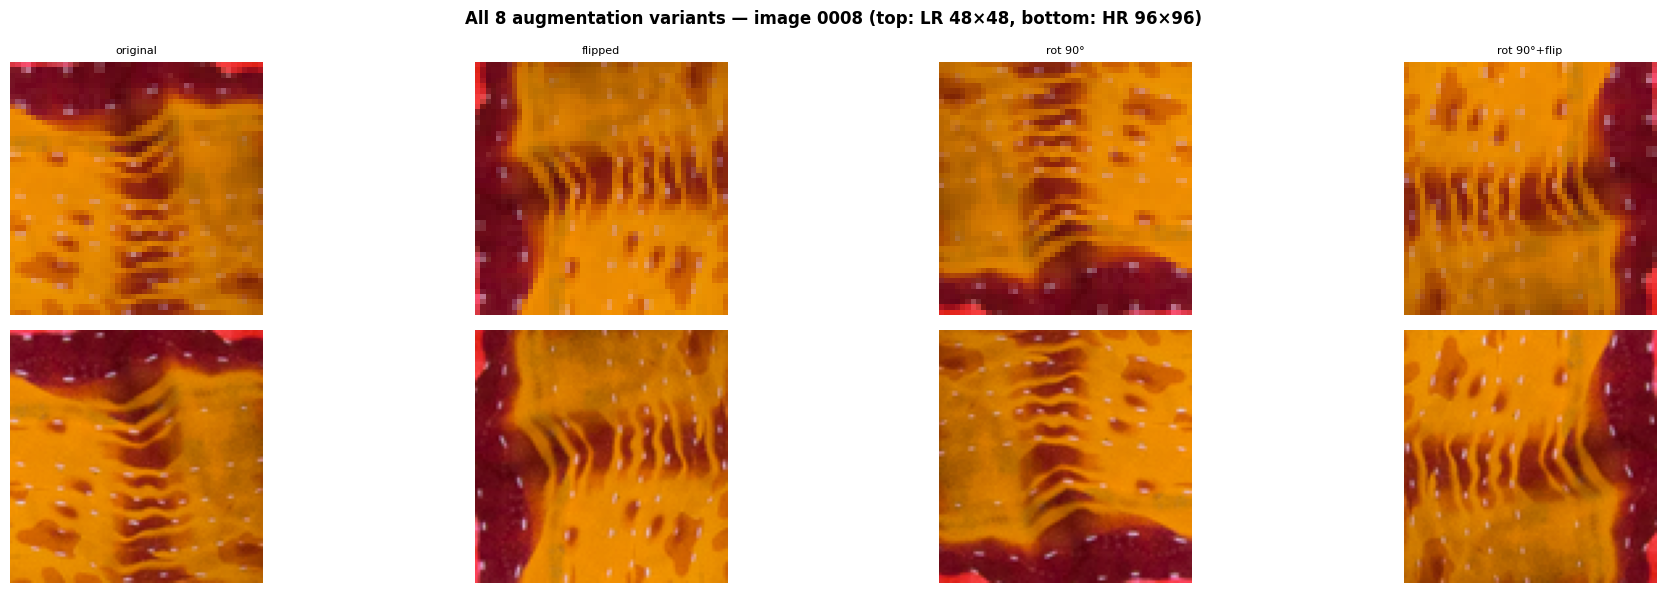

Preview saved → /content/drive/MyDrive/Deep_learning_project_Queens/new_samples/patches_Dataset/augmentation_preview.png


In [ ]:
# Pick one random HR image, extract one patch, show all 4 augmentations
sample_id = train_ids[0]
hr_img = mod_crop(Image.open(HR_DIR / f"{sample_id:04d}.png").convert("RGB"), SCALE)
lr_img = Image.open(LR_DIR / f"{sample_id:04d}x2.png").convert("RGB")

hr_arr = np.array(hr_img, dtype=np.float32) / 255.0
lr_arr = np.array(lr_img, dtype=np.float32) / 255.0

# Take a central patch for clarity
lr_w, lr_h = lr_img.size
cx = (lr_w - LR_PATCH) // 2
cy = (lr_h - LR_PATCH) // 2
lr_patch = lr_arr[cy:cy+LR_PATCH, cx:cx+LR_PATCH]
hr_patch = hr_arr[cy*SCALE:(cy+LR_PATCH)*SCALE, cx*SCALE:(cx+LR_PATCH)*SCALE]

variants = augment_pair(hr_patch, lr_patch)
labels = ["original", "flipped",
          "rot 90°", "rot 90°+flip",
          "rot 180°", "rot 180°+flip",
          "rot 270°", "rot 270°+flip"]

fig, axes = plt.subplots(2, 4, figsize=(20, 6))
fig.suptitle(f"All 8 augmentation variants — image {sample_id:04d} (top: LR 48×48, bottom: HR 96×96)",
             fontsize=12, fontweight="bold")

for col, ((hr_v, lr_v), lbl) in enumerate(zip(variants, labels)):
    axes[0, col].imshow(lr_v)
    axes[0, col].set_title(lbl, fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(hr_v)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "augmentation_preview.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Preview saved → {OUT_DIR / 'augmentation_preview.png'}")

## 8. PyTorch Dataset that loads from saved patches
Student A imports this class directly into the training notebook.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PatchDataset(Dataset):
    """
    Loads pre-extracted (LR, HR) patch pairs saved as .npy files.
    Much faster than on-the-fly extraction during training.

    Parameters
    ----------
    patch_dir : directory containing 'hr/' and 'lr/' subdirectories
    """
    def __init__(self, patch_dir: Path):
        self.hr_paths = sorted((patch_dir / "hr").glob("*.npy"))
        self.lr_paths = sorted((patch_dir / "lr").glob("*.npy"))
        assert len(self.hr_paths) == len(self.lr_paths), "Patch count mismatch"

    def __len__(self) -> int:
        return len(self.hr_paths)

    def __getitem__(self, idx: int):
        # Load numpy arrays: (H, W, 3) float32 in [0, 1]
        hr = np.load(self.hr_paths[idx])   # (96, 96, 3)
        lr = np.load(self.lr_paths[idx])   # (48, 48, 3)

        # Convert to PyTorch tensors: (3, H, W)
        hr_tensor = torch.from_numpy(hr.transpose(2, 0, 1))  # HWC → CHW
        lr_tensor = torch.from_numpy(lr.transpose(2, 0, 1))

        return lr_tensor, hr_tensor


# ── Quick test ───────────────────────────────────────────────────────────────
dataset = PatchDataset(TRAIN_DIR)
loader  = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

lr_batch, hr_batch = next(iter(loader))
print(f"Dataset size   : {len(dataset):,} patches")
print(f"LR batch shape : {lr_batch.shape}    (B, C, LR_H, LR_W)")
print(f"HR batch shape : {hr_batch.shape}   (B, C, HR_H, HR_W)")
print(f"Value range    : [{lr_batch.min():.2f}, {lr_batch.max():.2f}]")

Dataset size   : 98,646 patches
LR batch shape : torch.Size([8, 3, 48, 48])    (B, C, LR_H, LR_W)
HR batch shape : torch.Size([8, 3, 96, 96])   (B, C, HR_H, HR_W)
Value range    : [0.00, 1.00]


## 9. Save preprocessing metadata

In [ ]:
preprocess_meta = {
    "scale"           : SCALE,
    "hr_patch_size"   : HR_PATCH,
    "lr_patch_size"   : LR_PATCH,
    "stride_hr"       : STRIDE_HR,
    "stride_lr"       : STRIDE_LR,
    "augmentations"   : 8,
    "val_images"      : len(val_ids),
    "normalization"   : "divide by 255 → [0, 1]",
    "seed"            : SEED,
}

with open(OUT_DIR / "preprocess_meta.json", "w") as f:
    json.dump(preprocess_meta, f, indent=2)

print("Preprocessing metadata saved:")
print(json.dumps(preprocess_meta, indent=2))

Preprocessing metadata saved:
{
  "scale": 2,
  "hr_patch_size": 96,
  "lr_patch_size": 48,
  "stride_hr": 48,
  "stride_lr": 24,
  "augmentations": 8,
  "val_images": 10,
  "normalization": "divide by 255 \u2192 [0, 1]",
  "seed": 42
}


In [ ]:
print(len(list((VAL_DIR / "hr").glob("*.npy"))))
print(len(list((VAL_DIR / "lr").glob("*.npy"))))

10
10


HR validation files: 10
LR validation files: 10

Loaded successfully!
HR shape: (1356, 2040, 3)
LR shape: (678, 1020, 3)
HR range: 0.0 → 1.0
LR range: 0.0 → 1.0


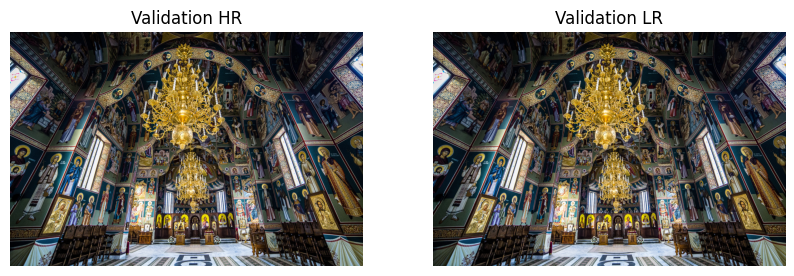

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── List validation files ─────────────────────────────
val_hr_files = sorted((VAL_DIR / "hr").glob("*.npy"))
val_lr_files = sorted((VAL_DIR / "lr").glob("*.npy"))

print(f"HR validation files: {len(val_hr_files)}")
print(f"LR validation files: {len(val_lr_files)}")

# ── Make sure files exist ─────────────────────────────
assert len(val_hr_files) > 0, "No HR validation files found!"
assert len(val_lr_files) > 0, "No LR validation files found!"

# ── Load first validation pair ────────────────────────
hr_arr = np.load(val_hr_files[0])
lr_arr = np.load(val_lr_files[0])

print("\nLoaded successfully!")
print("HR shape:", hr_arr.shape)
print("LR shape:", lr_arr.shape)

print("HR range:", hr_arr.min(), "→", hr_arr.max())
print("LR range:", lr_arr.min(), "→", lr_arr.max())

# ── Display images ────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(hr_arr)
ax[0].set_title("Validation HR")
ax[0].axis("off")

ax[1].imshow(lr_arr)
ax[1].set_title("Validation LR")
ax[1].axis("off")

plt.show()